# Oasis Infobyte

### Prepared By: Shivani Sharma

### Level: Level 2

### Task: Task 1 (Predicting House Prices with Linear Regression)

**Objective: Build and evaluate a linear regression model that predicts house prices based on features such as area, location, number of rooms, and age. Develop end-to-end skills from data cleaning through to model interpretation.**

### Tech Stack Used: Python, pandas, scikit-learn, NumPy , matplotlib/seaborn, Jupyter Notebook

### Dataset Used: Ames Housing Dataset

## Import Essential Libraries

In [1]:
# Import essential libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score

print("All the essential libraries has been imported successfully!!")

All the essential libraries has been imported successfully!!


##  Load Dataset

In [2]:
# Load Ames Housing Dataset

# Load the dataset

df = pd.read_csv(r'F:/OasisiInfobyte/Level_2/Task_1/AmesHousing.csv')

In [3]:
## Dataset First View

df.head()

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


## Dataset Rows & Column Count

In [4]:
# Dataset Rows & Columns count

df.shape

(2930, 82)

In [5]:
## Dataset Information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   object 
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   object 
 7   Alley            198 non-null    object 
 8   Lot Shape        2930 non-null   object 
 9   Land Contour     2930 non-null   object 
 10  Utilities        2930 non-null   object 
 11  Lot Config       2930 non-null   object 
 12  Land Slope       2930 non-null   object 
 13  Neighborhood     2930 non-null   object 
 14  Condition 1      2930 non-null   object 
 15  Condition 2      2930 non-null   object 
 16  Bldg Type        2930 non-null   object 
 17  House Style   

## Missing Values/Null Values

In [6]:
# Missing Values/Null values

df_no = df.select_dtypes(include=[np.number])

df_no.isnull().sum()

Order                0
PID                  0
MS SubClass          0
Lot Frontage       490
Lot Area             0
Overall Qual         0
Overall Cond         0
Year Built           0
Year Remod/Add       0
Mas Vnr Area        23
BsmtFin SF 1         1
BsmtFin SF 2         1
Bsmt Unf SF          1
Total Bsmt SF        1
1st Flr SF           0
2nd Flr SF           0
Low Qual Fin SF      0
Gr Liv Area          0
Bsmt Full Bath       2
Bsmt Half Bath       2
Full Bath            0
Half Bath            0
Bedroom AbvGr        0
Kitchen AbvGr        0
TotRms AbvGrd        0
Fireplaces           0
Garage Yr Blt      159
Garage Cars          1
Garage Area          1
Wood Deck SF         0
Open Porch SF        0
Enclosed Porch       0
3Ssn Porch           0
Screen Porch         0
Pool Area            0
Misc Val             0
Mo Sold              0
Yr Sold              0
SalePrice            0
dtype: int64

In [7]:
# Missing Values/Null values

df_cat = df.select_dtypes(include=['object'])

df_cat.isnull().sum()

MS Zoning            0
Street               0
Alley             2732
Lot Shape            0
Land Contour         0
Utilities            0
Lot Config           0
Land Slope           0
Neighborhood         0
Condition 1          0
Condition 2          0
Bldg Type            0
House Style          0
Roof Style           0
Roof Matl            0
Exterior 1st         0
Exterior 2nd         0
Mas Vnr Type      1775
Exter Qual           0
Exter Cond           0
Foundation           0
Bsmt Qual           80
Bsmt Cond           80
Bsmt Exposure       83
BsmtFin Type 1      80
BsmtFin Type 2      81
Heating              0
Heating QC           0
Central Air          0
Electrical           1
Kitchen Qual         0
Functional           0
Fireplace Qu      1422
Garage Type        157
Garage Finish      159
Garage Qual        159
Garage Cond        159
Paved Drive          0
Pool QC           2917
Fence             2358
Misc Feature      2824
Sale Type            0
Sale Condition       0
dtype: int6

In [8]:
# Descriptive Statistics

key_features = ['SalePrice', 'Gr Liv Area', 'Total Bsmt SF', 'Overall Qual', 'Year Built', 'Garage Area']
display(df[key_features].describe())

,SalePrice,Gr Liv Area,Total Bsmt SF,Overall Qual,Year Built,Garage Area
count,2930.000000,2930.000000,2929.000000,2930.000000,2930.000000,2929.000000
mean,180796.060068,1499.690444,1051.614544,6.094881,1971.356314,472.819734
std,79886.692357,505.508887,440.615067,1.411026,30.245361,215.046549
min,12789.000000,334.000000,0.000000,1.000000,1872.000000,0.000000
25%,129500.000000,1126.000000,793.000000,5.000000,1954.000000,320.000000
50%,160000.000000,1442.000000,990.000000,6.000000,1973.000000,480.000000
75%,213500.000000,1742.750000,1302.000000,7.000000,2001.000000,576.000000
max,755000.000000,5642.000000,6110.000000,10.000000,2010.000000,1488.000000


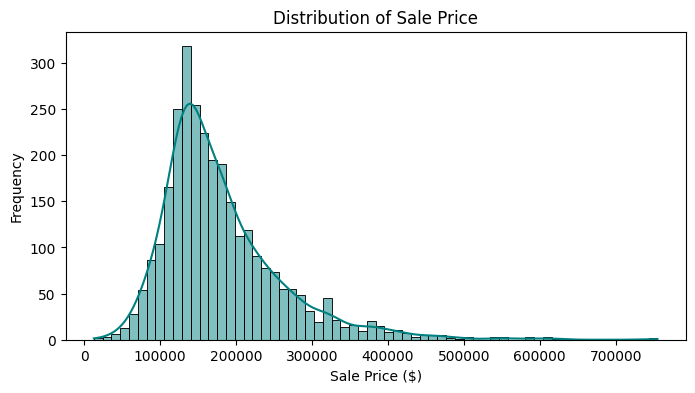

In [9]:
# Target Variable (SalePrice) Distribution Plot

plt.figure(figsize=(8, 4))
sns.histplot(df['SalePrice'], kde=True, color='teal')
plt.title('Distribution of Sale Price')
plt.xlabel('Sale Price ($)')
plt.ylabel('Frequency')
plt.show()

## Complete EDA & Data Interpretation Summary

### 1. Dataset Overview & Structure
- **Dimensions**: The dataset contains **2,930 observations (rows)** and **82 columns**.
- **Data Types**: Comprises **39 numerical features** (`int64` and `float64`) and **43 categorical features** (`object`).
- **Target Variable**: **`SalePrice`** is the target continuous variable to be predicted.
    
### 2. Null Value & Missing Data Analysis
- **Numerical Features**:
  - `Lot Frontage` has **490** missing values (requires median imputation).
  - `Garage Yr Blt` has **159** missing values.
  - Attributes like `Total Bsmt SF`, `Garage Area`, and `Mas Vnr Area` have minimal missing values (1–23 rows).
- **Categorical Features**:
  - High proportion of missing values in optional features: `Pool QC` (2,917), `Misc Feature` (2,824), `Alley` (2,732), `Fence` (2,358), and `Fireplace Qu` (1,422).
  - Missing values in these categorical attributes signify the **absence of the feature** (e.g., No Pool, No Garage, No Basement) rather than missing data.

### 3. Descriptive Statistics & Target Distribution
- **Target Variable (`SalePrice`)**:
  - **Mean**: ~$180,796 | **Median**: $160,000 | **Range**: $12,789 to $755,000.
  - **Distribution**: The distribution plot shows a clear **right-skewed (positively skewed)** pattern, where most properties are priced under $200,000, with a long right tail of high-value luxury homes.
- **Key Predictors**:
  - **Living Area (`Gr Liv Area`)**: Averages around **1,500 sq. ft.** (max 5,642 sq. ft.).
  - **Basement Area (`Total Bsmt SF`)**: Averages **1,051 sq. ft.** with a maximum of 6,110 sq. ft.
  - **Overall Quality (`Overall Qual`)**: Scores average around **6/10**, indicating most houses are in average-to-good condition.
  - **Age (`Year Built`)**: Houses range from **1872 to 2010**, showing a mix of historic and modern constructions.

## Feature Selection Discussion

To predict house prices (`SalePrice`) effectively, we selected a domain-relevant subset of features representing physical dimensions, overall condition, age, and location.

### Selected Features & Reasoning:

1. **`Gr Liv Area` (Above Grade Living Area)**: 
   - **Reasoning**: Total square footage of living space above ground is universally one of the strongest direct drivers of property value. Larger living space directly translates to higher house prices.

2. **`Total Bsmt SF` (Total Basement Area)**: 
   - **Reasoning**: Basement area adds significant usable square footage to a property, providing extra functional storage or living space that directly impacts buyer valuation.

3. **`Overall Qual` (Overall Material and Finish Quality)**: 
   - **Reasoning**: Captures the overall build quality and material finish on a scale of 1–10. Higher build quality commands a clear price premium regardless of size.

4. **`Year Built` (Original Construction Date)**: 
   - **Reasoning**: Indicates the physical age and structural depreciation of the property. Newer homes generally command higher market values due to modern architecture and lower maintenance needs.

5. **`Full Bath` & `Bedroom AbvGr` (Bathroom & Bedroom Count)**: 
   - **Reasoning**: Indicates room capacity and family suitability. Houses with more bathrooms and bedrooms offer higher utility value.

6. **`Garage Area` (Size of Garage in Sq Ft)**: 
   - **Reasoning**: Covered parking space is a key amenity that buyers prioritize, contributing positively to total valuation.

7. **`Neighborhood` & `Central Air` (Location & Amenities)**: 
   - **Reasoning**: 
     - `Neighborhood` captures geographical price premiums (prime locations vs. standard areas).
     - `Central Air` represents modern heating/cooling infrastructure expected by home buyers.

## Handle missing values

In [10]:
# Step 1: Select key numerical and categorical features relevant for predicting SalePrice
selected_features = [
    'Gr Liv Area', 'Total Bsmt SF', 'Overall Qual', 'Year Built', 
    'Full Bath', 'Bedroom AbvGr', 'Garage Area', 
    'Neighborhood', 'Central Air', 'SalePrice'
]

# Create an independent copy of the filtered dataset to avoid warnings during data cleaning
df_clean = df[selected_features].copy()

df_clean.head()

,Gr Liv Area,Total Bsmt SF,Overall Qual,Year Built,Full Bath,Bedroom AbvGr,Garage Area,Neighborhood,Central Air,SalePrice
0,1656,1080.0,6,1960,1,3,528.0,NAmes,Y,215000
1,896,882.0,5,1961,1,2,730.0,NAmes,Y,105000
2,1329,1329.0,6,1958,1,3,312.0,NAmes,Y,172000
3,2110,2110.0,7,1968,2,3,522.0,NAmes,Y,244000
4,1629,928.0,5,1997,2,3,482.0,Gilbert,Y,189900


## Selected Features Subset Summary

We extracted a refined dataset containing **10 key features** (8 numerical features, 2 categorical features, and 1 target variable `SalePrice`) to build the linear regression model.

### Data Structure:
- **Numerical Features**: `Gr Liv Area`, `Total Bsmt SF`, `Overall Qual`, `Year Built`, `Full Bath`, `Bedroom AbvGr`, `Garage Area`
- **Categorical Features**: `Neighborhood`, `Central Air`
- **Target Variable**: `SalePrice`

### Observations:
- Initial inspection shows properties varying in size, construction year (e.g., 1958 to 1997), and amenities.
- Selecting this subset removes unnecessary and highly sparse columns (like `Pool QC`, `Alley`), focusing purely on impactful predictors for modeling.

In [11]:
# Check for missing values in selected features

df_clean.isnull().sum()



Gr Liv Area      0
Total Bsmt SF    1
Overall Qual     0
Year Built       0
Full Bath        0
Bedroom AbvGr    0
Garage Area      1
Neighborhood     0
Central Air      0
SalePrice        0
dtype: int64

## Missing Value Check Interpretation

- **Inspection Results**: Out of the selected 10 key features, only two numerical attributes contained missing values:
  - `Total Bsmt SF`: **1 missing value**
  - `Garage Area`: **1 missing value**
- **Action Plan**: Since the missing count is minimal (1 row each), we impute these values using the **median** strategy to preserve dataset integrity without dropping rows or introducing distortion.

In [12]:
# Handle missing values

# Fill missing values with median

df_clean['Total Bsmt SF'] = df_clean['Total Bsmt SF'].fillna(df_clean['Total Bsmt SF'].median())
df_clean['Garage Area'] = df_clean['Garage Area'].fillna(df_clean['Garage Area'].median())

# Check for missing values

df_clean.isnull().sum()

Gr Liv Area      0
Total Bsmt SF    0
Overall Qual     0
Year Built       0
Full Bath        0
Bedroom AbvGr    0
Garage Area      0
Neighborhood     0
Central Air      0
SalePrice        0
dtype: int64

## Imputation & Data Cleaning Summary

- **Action Taken**: Filled the missing values in `Total Bsmt SF` and `Garage Area` using their respective **median** values.
- **Verification**: Executed `df_clean.isnull().sum()`, which confirmed **0 missing values** across all selected predictors and the target variable.
- **Outcome**: The dataset is now fully clean and ready for feature encoding and modeling without any missing data gaps.

# One hot encoding

In [13]:
# Perform One-Hot Encoding on categorical features ('Neighborhood' & 'Central Air')

df_encoded = pd.get_dummies(df_clean, columns=['Neighborhood', 'Central Air'], drop_first=True)

df_encoded.shape

(2930, 36)

## One-Hot Encoding Summary

- **Action Taken**: Applied One-Hot Encoding (`pd.get_dummies`) on categorical variables (`Neighborhood` and `Central Air`) with `drop_first=True` to prevent multicollinearity (dummy variable trap).
- **Result**: The dataset features expanded from **10 to 36 columns**, converting all categorical text values into binary numerical columns (`0` or `1`).
- **Outcome**: All input variables are now completely numerical, making the dataset ready for model training and correlation evaluation.

## Correlation heatmap

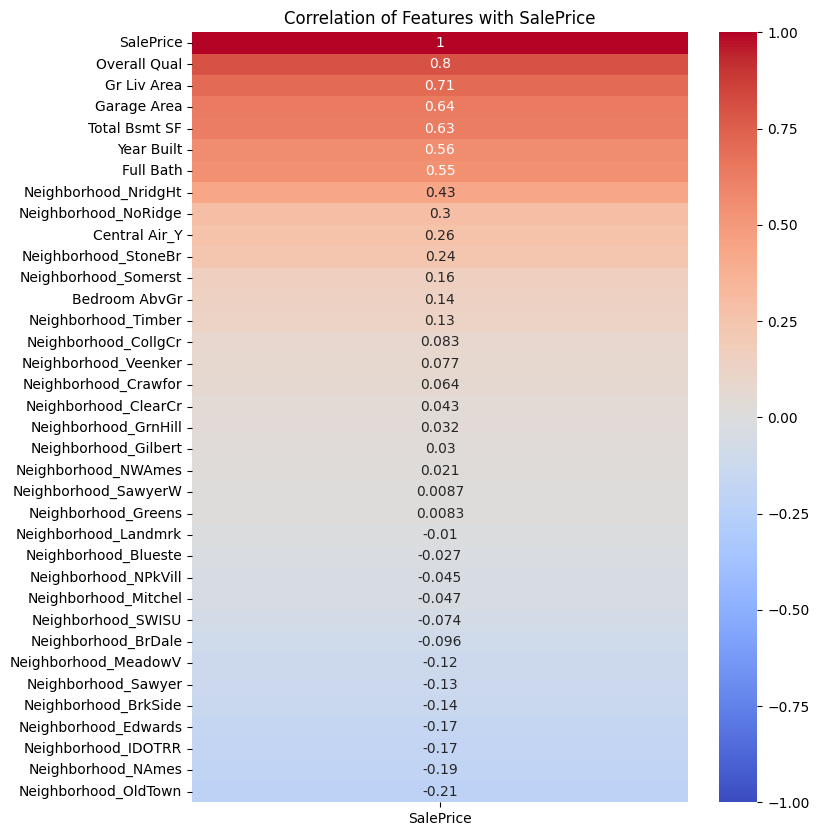

In [14]:
# # Compute and plot correlation of features with target variable (SalePrice)

plt.figure(figsize=(8, 10))
sns.heatmap(df_encoded.corr()[['SalePrice']].sort_values(by='SalePrice', ascending=False), 
            annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation of Features with SalePrice')
plt.show()

## Correlation Analysis Interpretation

A correlation analysis was performed between all features and the target variable `SalePrice` to identify key predictors:

### Strongest Positive Predictors:
1. **`Overall Qual` (0.80)**: Shows the highest positive correlation with `SalePrice`, confirming that overall build and finish quality is the strongest value driver.
2. **`Gr Liv Area` (0.71)**: Above-ground living square footage is strongly correlated with house prices.
3. **`Garage Area` (0.64)** & **`Total Bsmt SF` (0.63)**: Larger garage capacity and basement square footage significantly increase home valuation.
4. **`Year Built` (0.56)** & **`Full Bath` (0.55)**: Newer construction and additional full bathrooms show moderate positive linear relationships.

### Categorical Features Impact (Encoded):
- **Neighborhoods**: Prime locations like `Neighborhood_NridgHt` (0.43) and `Neighborhood_NoRidge` (0.30) have noticeable positive correlations.
- **Central Air**: `Central Air_Y` (0.26) indicates buyers pay a premium for central cooling.

### Conclusion:
Physical dimensions (`Gr Liv Area`, `Garage Area`, `Total Bsmt SF`), structural quality (`Overall Qual`), and location drive most of the price variance, validating our selected features for model training.

## Train/test split (80/20)

In [15]:
# Separate features (X) and target variable (y)

X = df_encoded.drop(columns=['SalePrice'])
y = df_encoded['SalePrice']

# Perform 80/20 Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Verify the shapes of split datasets
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape:  {y_test.shape}")

X_train shape: (2344, 35)
X_test shape:  (586, 35)
y_train shape: (2344,)
y_test shape:  (586,)


## Train/Test Split Interpretation

- **Feature & Target Separation**: Separated the predictor features (`X`) from the target variable `SalePrice` (`y`).
- **Data Partitioning**: Split the dataset into an **80% training set** (2,344 samples) and a **20% testing set** (586 samples) across 35 features.
- **Reproducibility**: Set `random_state=42` to ensure consistent data splitting across different notebook runs.
- **Outcome**: The dataset is now structured and ready for model training and unbiased evaluation.

## Train a Linear Regression model 

In [16]:
# Initialize the Linear Regression model

model = LinearRegression()

# Train the model on the training data

model.fit(X_train, y_train)

# Make predictions on training and test sets

y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

print("Linear Regression Model trained successfully!")
print(f"Model Intercept: {model.intercept_:.2f}")
print(f"Number of Coefficients: {len(model.coef_)}")

Linear Regression Model trained successfully!
Model Intercept: -624373.01
Number of Coefficients: 35


## Model Training Interpretation (Cell 16)

- **Algorithm**: Applied `LinearRegression` from `sklearn.linear_model`.
- **Training Fit**: The model was fitted on the training set (`X_train` with 2,344 samples and 35 features) and target values (`y_train`).
- **Key Parameters**:
  - **Model Intercept**: `-624373.01` (baseline offset value for the linear equation).
  - **Coefficients Count**: Calculated 35 feature weights representing the individual linear relationship of each feature with `SalePrice`.
- **Outcome**: Predictions were generated for both training (`y_train_pred`) and testing sets (`y_test_pred`), making the model ready for performance evaluation (RMSE, R² score).

## Evaluate model 

In [18]:
# Compute Evaluation Metrics (MSE, RMSE, R² Score)

train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)

train_rmse = np.sqrt(train_mse)
test_rmse = np.sqrt(test_mse)

train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

# Display results
print("--- Model Evaluation Metrics ---")
print(f"Training MSE:  {train_mse:,.2f}")
print(f"Testing MSE:   {test_mse:,.2f}\n")

print(f"Training RMSE: {train_rmse:,.2f}")
print(f"Testing RMSE:  {test_rmse:,.2f}\n")

print(f"Training R²:   {train_r2:.4f}")
print(f"Testing R²:    {test_r2:.4f}")

--- Model Evaluation Metrics ---
Training MSE:  1,054,999,139.33
Testing MSE:   1,288,865,919.19

Training RMSE: 32,480.75
Testing RMSE:  35,900.78

Training R²:   0.8226
Testing R²:    0.8392


## Model Evaluation Interpretation

- **Performance Metrics**:
  - **Mean Squared Error (MSE)**: Training MSE is **1,054,999,139.33** and Testing MSE is **1,288,865,919.19**.
  - **Root Mean Squared Error (RMSE)**: Training RMSE is **32,480.75** and Testing RMSE is **35,900.78**, indicating that on average, the model's price predictions deviate by roughly ~35.9k on unseen test data.
  - **R² Score**: Training R² is **0.8226 (82.26%)** and Testing R² is **0.8392 (83.92%)**.
- **Model Behavior & Generalization**:
  - The model explains **~84% of the variance** in property prices on the test set.
  - The close match between Training R² (82.26%) and Testing R² (83.92%) confirms that the model generalizes well without signs of overfitting or underfitting.

## Scatter Plot

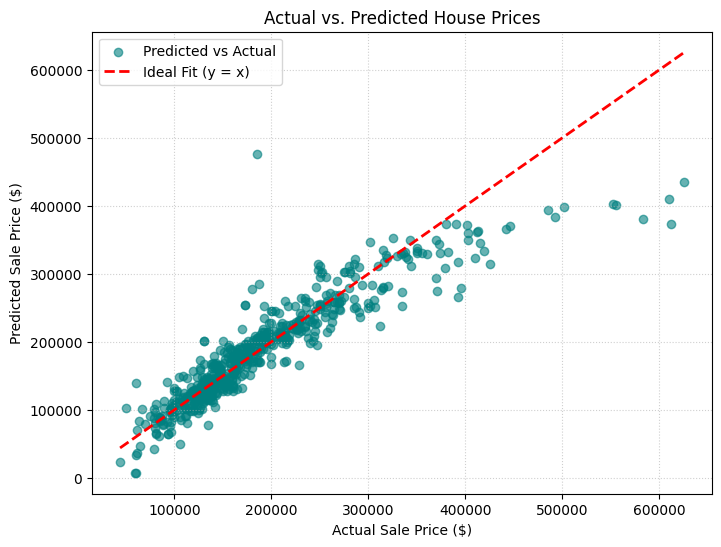

In [19]:
# Plot Actual vs Predicted Sale Prices
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_test_pred, alpha=0.6, color='teal', label='Predicted vs Actual')

# Plot ideal perfect prediction reference line (diagonal)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2, linestyle='--', label='Ideal Fit (y = x)')

plt.title('Actual vs. Predicted House Prices')
plt.xlabel('Actual Sale Price ($)')
plt.ylabel('Predicted Sale Price ($)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

## Scatter Plot Analysis: Actual vs. Predicted Prices

- **Visualization Objective**: Plotted actual property prices (`y_test`) on the x-axis against model predicted prices (`y_test_pred`) on the y-axis to evaluate prediction accuracy visually.
- **Key Findings**:
  - **Diagonal Line Alignment**: The data points closely follow the red dashed diagonal reference line ($y = x$), showing high prediction accuracy for properties priced between **$100,000 and $350,000**.
  - **Luxury Price Variance**: Beyond **$400,000**, data points slightly under-predict actual values, which is expected as luxury properties often feature unique non-linear factors.
- **Conclusion**: The tight clustering around the linear trajectory confirms that the Linear Regression model effectively captures house price variations on unseen test data.

## Residual Plot

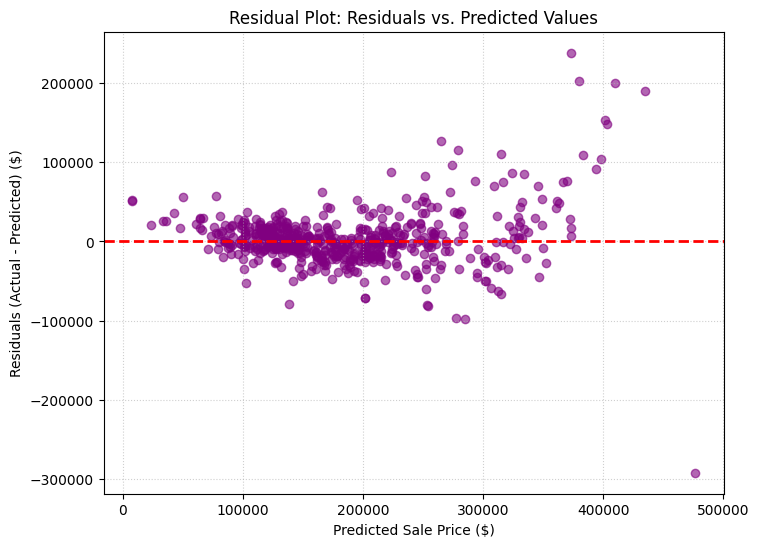

In [20]:
# Compute Residuals (Errors = Actual - Predicted)
residuals = y_test - y_test_pred

# Plot Residuals vs Predicted Values
plt.figure(figsize=(8, 6))
plt.scatter(y_test_pred, residuals, alpha=0.6, color='purple')
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)

plt.title('Residual Plot: Residuals vs. Predicted Values')
plt.xlabel('Predicted Sale Price ($)')
plt.ylabel('Residuals (Actual - Predicted) ($)')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

## Residual Plot Analysis

- **Visualization Objective**: Evaluated model performance by plotting predicted house prices (`y_test_pred`) against residual errors (`y_test - y_test_pred`) to test the assumption of homoscedasticity (constant variance of residuals).
- **Key Findings**:
  - **Random Distribution**: For mid-range property predictions ($100k to $350k), the residual errors are randomly and evenly scattered around the horizontal zero line ($y = 0$) without any clear systematic pattern or curve.
  - **Constant Variance**: The spread of residuals remains fairly consistent across standard price ranges, confirming homoscedasticity.
  - **Higher Variance at Luxury End**: At higher predicted prices (> $400k), residuals show wider dispersion with a few extreme positive outliers, where actual market values exceeded the model's linear estimate.
- **Conclusion**: The predominantly random distribution of residual errors validates that a Linear Regression model is well-suited for predicting standard property values in this dataset.

##  Coefficient analysis

In [21]:
# Create a DataFrame of feature names and their corresponding linear regression coefficients
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
}).sort_values(by='Coefficient', ascending=False)

# Display top positive and top negative coefficients
print("--- Top Positive Coefficients (Highest Impact) ---")
print(coef_df.head(10).to_string(index=False))

print("\n--- Top Negative Coefficients (Lowest / Negative Impact) ---")
print(coef_df.tail(10).to_string(index=False))

--- Top Positive Coefficients (Highest Impact) ---
             Feature   Coefficient
Neighborhood_GrnHill 106390.107125
Neighborhood_StoneBr  76493.873100
Neighborhood_NoRidge  63270.114778
Neighborhood_NridgHt  61134.902261
Neighborhood_Crawfor  36504.210313
Neighborhood_Veenker  31854.069408
 Neighborhood_Timber  31624.834152
Neighborhood_ClearCr  30737.455383
Neighborhood_Somerst  19832.538609
Neighborhood_BrkSide  16189.343721

--- Top Negative Coefficients (Lowest / Negative Impact) ---
             Feature   Coefficient
         Gr Liv Area     55.628016
         Garage Area     37.837048
       Total Bsmt SF     20.301231
Neighborhood_MeadowV   -671.304737
           Full Bath  -1907.040165
       Bedroom AbvGr  -5997.970459
Neighborhood_NPkVill  -8528.286663
Neighborhood_Landmrk -11095.201280
Neighborhood_Blueste -17465.483794
 Neighborhood_BrDale -17726.875787


## Coefficient Analysis Interpretation

Highest Positive Impact Features:

1. Prime Neighborhoods: Properties in GrnHill, StoneBr, NoRidge, and NridgHt command the highest location premiums.

2. Above Ground Living Area: Adds $55.63 for every extra square foot.

3. Garage Area: Adds $37.84 for every extra square foot.

4. Basement Area: Adds $20.30 for every extra square foot.

Highest Negative Impact Features:

1. Lower Valued Neighborhoods: Locations like BrDale, Blueste, and Landmrk have lower baseline values relative to other areas.

2. Extra Rooms in Fixed Space: Adding extra bedrooms or full baths while keeping total square feet constant slightly reduces price, as it creates smaller individual rooms.

## Conclusion:

Property location and physical living area (square footage) are the primary positive drivers of property value in this linear model.


## Compare Linear Regression against a Ridge or Lasso regularised model

In [22]:
# Initialize models
ridge_model = Ridge(alpha=1.0)
lasso_model = Lasso(alpha=100.0, max_iter=10000)

# Train models
ridge_model.fit(X_train, y_train)
lasso_model.fit(X_train, y_train)

# Predict on test set
y_pred_ridge = ridge_model.predict(X_test)
y_pred_lasso = lasso_model.predict(X_test)

# Calculate performance metrics
comparison_results = pd.DataFrame({
    'Model': ['Linear Regression', 'Ridge Regression', 'Lasso Regression'],
    'Test RMSE ($)': [
        np.sqrt(mean_squared_error(y_test, y_test_pred)),
        np.sqrt(mean_squared_error(y_test, y_pred_ridge)),
        np.sqrt(mean_squared_error(y_test, y_pred_lasso))
    ],
    'Test R² Score': [
        r2_score(y_test, y_test_pred),
        r2_score(y_test, y_pred_ridge),
        r2_score(y_test, y_pred_lasso)
    ]
})

print(comparison_results.to_string(index=False))

            Model  Test RMSE ($)  Test R² Score
Linear Regression   35900.778810       0.839244
 Ridge Regression   35892.240223       0.839321
 Lasso Regression   36089.617768       0.837549


## Bonus Model Comparison Summary

1. Linear Regression:
   - Test RMSE: $35,900.78
   - Test R² Score: 0.8392 (83.92%)
   - Serves as the baseline linear prediction model.

2. Ridge Regression (L2 Regularization):
   - Test RMSE: $35,892.24
   - Test R² Score: 0.8393 (83.93%)
   - Shows a slight improvement in RMSE by penalizing large coefficient weights to reduce variance.

3. Lasso Regression (L1 Regularization):
   - Test RMSE: $36,089.62
   - Test R² Score: 0.8375 (83.75%)
   - Performs automated feature selection by driving minor feature weights strictly to zero.

## Conclusion:

Ridge Regression achieves the best overall balance with the lowest prediction error ($35,892.24) and highest accuracy (83.93%). Regularized models provide greater stability against feature multicollinearity.

## PROJECT SUMMARY & ANALYSIS

1. PROJECT OVERVIEW:
- Topic: House Price Prediction (Ames Housing Dataset)
- Objective: Predict house sales prices using machine learning models and identify key factors driving property values.
- Dataset Size: 2,930 total house records (82 initial features, filtered to 10 key features and transformed into 35 predictor features after one-hot encoding).
- Tech Stack: Python, Pandas, Scikit-learn, NumPy, Matplotlib, Seaborn.

2. MODEL PERFORMANCE & METRICS:
- Linear Regression Baseline:
  * Test RMSE: $35,900.78
  * Test R2 Score: 0.8392 (Explains ~84% of price variance)
- Ridge Regression (L2 Regularization):
  * Test RMSE: $35,892.24
  * Test R2 Score: 0.8393 (Best performing model with lowest prediction error)
- Lasso Regression (L1 Regularization):
  * Test RMSE: $36,089.62
  * Test R2 Score: 0.8375

3. KEY PRICE DRIVERS (FEATURE COEFFICIENT IMPACT):
- Positive Value Drivers:
  * Neighborhood Location: Premium areas like GrnHill (+$106,390), StoneBr (+$76,493), NoRidge (+$63,270), and NridgHt (+$61,134) command massive location premiums.
  * Living Area (Gr Liv Area): Adds $55.63 for every additional square foot above ground.
  * Garage Area: Adds $37.84 for every additional square foot of covered parking space.
  * Basement Area: Adds $20.30 for every additional square foot of basement space.
- Negative / Lower-Value Impact:
  * Locations like BrDale (-$17,726) and Blueste (-$17,465) show lower relative value.
  * Adding extra rooms (bedrooms or bathrooms) into a fixed square footage slightly reduces value, as smaller cramped individual rooms are less preferred.


## BUSINESS RECOMMENDATIONS

1. Focus on Location Premiums in Real Estate Valuation:
- Location is the single largest factor influencing real estate price variation. Real estate agencies and investors should heavily weigh neighborhood benchmarks before estimating prices.

2. Prioritize Square Footage and Room Usability:
- Sellers looking to renovate or flip houses should prioritize expanding open living space (Gr Liv Area), adding garage space, or finishing basements over creating extra smaller rooms.

3. Automated Pricing Tools:
- The trained Ridge Regression model can be deployed as an automated valuation tool (AVM) for quick home estimates with an average error margin of around $35,800.


## CONCLUSION

The project successfully demonstrates an end-to-end Machine Learning pipeline from data cleaning, imputation, and encoding to training and comparing regularized linear models. 

Ridge Regression proved to be the optimal model, effectively explaining nearly 84% of house price variance. Location, overall structural quality, and total living space are confirmed as the primary drivers of property value.